**Machine Translation using Helsinki-NLP MarianMT Model**

**Data Preparation**

- download file from OPUS (Open Parallel Corpus)
- sample_siz: use 30,000 samples pairs
- split the dataset into 80% training set, 10% validation set and 10% test set

In [1]:
import requests
import zipfile
import io
import numpy as np
import pickle
from tqdm import tqdm
import os

# Set random seed
np.random.seed(42)

def download_and_load_data(url, sample_size=30000):
    """Download and load parallel corpus"""
    print("Downloading dataset...")
    print(f"URL: {url}")
    
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    # Download with progress bar
    content = io.BytesIO()
    with tqdm(total=total_size, unit='B', unit_scale=True, desc="Downloading") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            content.write(chunk)
            pbar.update(len(chunk))
    
    content.seek(0)
    
    print("\nExtracting files...")
    with zipfile.ZipFile(content) as z:
        files = z.namelist()
        print(f"Files in archive: {files}")
        
        # Find the appropriate files
        en_file = [f for f in files if 'OpenSubtitles.en-zh_CN.en' in f][0]
        zh_file = [f for f in files if 'OpenSubtitles.en-zh_CN.zh_CN' in f][0]
        
        print(f"Reading English file: {en_file}")
        with z.open(en_file) as f:
            en_lines = [line.decode('utf-8').strip() for line in f.readlines()]
        
        print(f"Reading Chinese file: {zh_file}")
        with z.open(zh_file) as f:
            zh_lines = [line.decode('utf-8').strip() for line in f.readlines()]
    
    print(f"\nTotal lines - EN: {len(en_lines)}, ZH: {len(zh_lines)}")
    
    # Filter valid pairs
    print("Filtering valid sentence pairs...")
    valid_pairs = []
    for zh, en in tqdm(zip(zh_lines, en_lines), total=len(zh_lines), desc="Filtering"):
        if (len(zh.strip()) > 0 and len(en.strip()) > 0 and 
            len(zh.split()) <= 50 and len(en.split()) <= 50 and
            len(zh) < 200 and len(en) < 200):  # Add length constraints
            valid_pairs.append((zh, en))
    
    print(f"Valid pairs after filtering: {len(valid_pairs)}")
    
    # Sample to reduce training time
    if len(valid_pairs) > sample_size:
        print(f"Sampling {sample_size} pairs from {len(valid_pairs)} valid pairs...")
        indices = np.random.choice(len(valid_pairs), sample_size, replace=False)
        valid_pairs = [valid_pairs[i] for i in indices]
    
    zh_texts, en_texts = zip(*valid_pairs)
    
    print(f"\nFinal dataset size: {len(zh_texts)} parallel sentences")
    
    # Show some examples
    print("\nSample sentence pairs:")
    for i in range(min(5, len(zh_texts))):
        print(f"\n{i+1}. ZH: {zh_texts[i]}")
        print(f"   EN: {en_texts[i]}")
    
    return list(zh_texts), list(en_texts)

def split_data(zh_texts, en_texts, train_ratio=0.8, val_ratio=0.1):
    """Split data into train, validation, and test sets"""
    n = len(zh_texts)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)
    
    print(f"\nSplitting data:")
    print(f"  Total: {n}")
    print(f"  Train: {train_size} ({train_ratio*100}%)")
    print(f"  Val: {val_size} ({val_ratio*100}%)")
    print(f"  Test: {n - train_size - val_size} ({(1-train_ratio-val_ratio)*100}%)")
    
    train_zh = zh_texts[:train_size]
    train_en = en_texts[:train_size]
    
    val_zh = zh_texts[train_size:train_size+val_size]
    val_en = en_texts[train_size:train_size+val_size]
    
    test_zh = zh_texts[train_size+val_size:]
    test_en = en_texts[train_size+val_size:]
    
    return (train_zh, train_en), (val_zh, val_en), (test_zh, test_en)

def save_data(train_data, val_data, test_data, output_dir='data'):
    """Save processed data to pickle files"""
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"\nSaving data to {output_dir}/...")
    
    with open(f'{output_dir}/train_data.pkl', 'wb') as f:
        pickle.dump(train_data, f)
    print(f"  ✓ Saved train_data.pkl")
    
    with open(f'{output_dir}/val_data.pkl', 'wb') as f:
        pickle.dump(val_data, f)
    print(f"  ✓ Saved val_data.pkl")
    
    with open(f'{output_dir}/test_data.pkl', 'wb') as f:
        pickle.dump(test_data, f)
    print(f"  ✓ Saved test_data.pkl")
    
    # Save summary
    summary = {
        'train_size': len(train_data[0]),
        'val_size': len(val_data[0]),
        'test_size': len(test_data[0]),
        'total_size': len(train_data[0]) + len(val_data[0]) + len(test_data[0])
    }
    
    with open(f'{output_dir}/data_summary.pkl', 'wb') as f:
        pickle.dump(summary, f)
    print(f"  ✓ Saved data_summary.pkl")
    
    print("\nAll data files saved successfully!")
    print(f"\nTo use this data in training, load with:")
    print(f"  with open('{output_dir}/train_data.pkl', 'rb') as f:")
    print(f"      train_data = pickle.load(f)")

def main():
    print("="*80)
    print("DATA PREPARATION FOR MANDARIN-ENGLISH TRANSLATION")
    print("="*80)
    
    # Configuration
    url = "https://object.pouta.csc.fi/OPUS-OpenSubtitles/v2024/moses/en-zh_CN.txt.zip"
    sample_size = 30000
    output_dir = 'data'
    
    # Check if data already exists
    if os.path.exists(f'{output_dir}/train_data.pkl'):
        response = input(f"\nData files already exist in '{output_dir}/'. Redownload? (y/n): ")
        if response.lower() != 'y':
            print("Skipping download. Using existing data.")
            return
    
    # Download and process
    zh_texts, en_texts = download_and_load_data(url, sample_size=sample_size)
    
    # Split data
    train_data, val_data, test_data = split_data(zh_texts, en_texts)
    
    # Save data
    save_data(train_data, val_data, test_data, output_dir=output_dir)
    
    print("\n" + "="*80)
    print("DATA PREPARATION COMPLETE!")
    print("="*80)
    print(f"\nYou can now run the training script without downloading again.")

if __name__ == "__main__":
    main()

DATA PREPARATION FOR MANDARIN-ENGLISH TRANSLATION
URL: https://object.pouta.csc.fi/OPUS-OpenSubtitles/v2024/moses/en-zh_CN.txt.zip


Downloading: 100%|██████████| 594M/594M [16:57<00:00, 584kB/s]   



Extracting files...
Files in archive: ['OpenSubtitles.en-zh_CN.en', 'OpenSubtitles.en-zh_CN.zh_CN', 'README', 'LICENSE']
Reading English file: OpenSubtitles.en-zh_CN.en
Reading Chinese file: OpenSubtitles.en-zh_CN.zh_CN

Total lines - EN: 22394812, ZH: 22394812
Filtering valid sentence pairs...


Filtering: 100%|██████████| 22394812/22394812 [00:19<00:00, 1166882.74it/s]


Valid pairs after filtering: 22373739
Sampling 30000 pairs from 22373739 valid pairs...

Final dataset size: 30000 parallel sentences

Sample sentence pairs:

1. ZH: 随时都可以得到
   EN: Readily available

2. ZH: 你记得我说的宇宙聚合吗？
   EN: Do you recall what I taught you of the Convergence?

3. ZH: 没有人要迈这一步 -没有这一步！
   EN: There is no step for anyone.

4. ZH: 你们做我的客人吧.
   EN: You'll be my guests.

5. ZH: ‎杰克 一旦你和群体意念相连接 ‎就不能轻易退出
   EN: Jack, once you're connected to the Egregore, you can't just disconnect.

Splitting data:
  Total: 30000
  Train: 24000 (80.0%)
  Val: 3000 (10.0%)
  Test: 3000 (9.999999999999995%)

Saving data to data/...
  ✓ Saved train_data.pkl
  ✓ Saved val_data.pkl
  ✓ Saved test_data.pkl
  ✓ Saved data_summary.pkl

All data files saved successfully!

To use this data in training, load with:
  with open('data/train_data.pkl', 'rb') as f:
      train_data = pickle.load(f)

DATA PREPARATION COMPLETE!

You can now run the training script without downloading again.


**Import Library**
- Set random seeds for reproducibility(every time run the code, get the same results, even if it involves randomness.)

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import MarianMTModel, MarianTokenizer, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
from collections import defaultdict
import os
from sacrebleu import corpus_bleu

torch.manual_seed(42)
np.random.seed(42)

**Dataset Class and Data Loader**
- parallel translation data from Mandarin to English
- pads sentences to a fixed length
- converts text into tensors suitable for the model

In [ ]:
class TranslationDataset(Dataset):
    """src_texts=source texts (Mandarin), tgt_texts=target texts(English)"""
    def __init__(self, src_texts, tgt_texts, tokenizer, max_length=128):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = self.src_texts[idx]
        tgt = self.tgt_texts[idx]
        # Tokenize source and target (returns tensors of shape [1, max_length])
        src_enc = self.tokenizer(src, max_length=self.max_length, 
                                 padding='max_length',#Adds padding tokens at the end to make all sequences in the batch the same length
                                 truncation=True, #If the sentence is too long, it will cut off extra tokens to fit max_length
                                 return_tensors='pt')#Converts the token IDs and attention masks into PyTorch tensors
        
        tgt_enc = self.tokenizer(tgt, max_length=self.max_length, 
                                 padding='max_length',
                                 truncation=True, 
                                 return_tensors='pt')
        return {
            'input_ids': src_enc['input_ids'].squeeze(0),# shape: (max_length,)
            'attention_mask': src_enc['attention_mask'].squeeze(0),
            'labels': tgt_enc['input_ids'].squeeze(0)
        }


**Translation Trainer Class**

- Trains the model for one epoch over the DataLoader
- Uses gradient clipping to stabilize training and gradient explosion
- Evaluates the model on validation or test data
- BLEU is a standard metric for measuring translation quality based on n-gram overlap
- Saves the best model based on BLEU

In [ ]:
class TranslationTrainer:
    """Trainer for neural machine translation (supports mixed precision)"""
    def __init__(self, model, tokenizer, device, use_amp=True):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.history = defaultdict(list)
        self.use_amp = use_amp and (device.type == 'cuda')
        self.scaler = torch.cuda.amp.GradScaler() if self.use_amp else None

    # scheduler: learning rate scheduler, adjusts learning rate during training
    def train_epoch(self, dataloader, optimizer, scheduler=None):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0.0
        for step, batch in enumerate(tqdm(dataloader, desc="Training")):
            batch = {k: v.to(self.device) for k, v in batch.items()}
            batch['labels'][batch['labels'] == self.tokenizer.pad_token_id] = -100
            optimizer.zero_grad()
            if self.use_amp:
                with torch.cuda.amp.autocast():
                    outputs = self.model(input_ids=batch['input_ids'],
                                         attention_mask=batch['attention_mask'],
                                         labels=batch['labels'])
                    loss = outputs.loss
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(optimizer)
                self.scaler.update()
            else:
                outputs = self.model(input_ids=batch['input_ids'],
                                     attention_mask=batch['attention_mask'],
                                     labels=batch['labels'])
                loss = outputs.loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
            if scheduler: scheduler.step()
            total_loss += loss.item()
        return total_loss / len(dataloader)

    # evaluate model, generate translations, compute BLEU score
    def evaluate(self, dataloader, max_batches=None):
        self.model.eval()
        total_loss = 0.0
        all_predictions = []
        all_references = []
        batches = list(dataloader)[:max_batches] if max_batches else dataloader
        with torch.no_grad():
            for batch in tqdm(batches, desc="Evaluating"):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                labels_eval = batch['labels'].clone()
                labels_eval[labels_eval == self.tokenizer.pad_token_id] = -100
                outputs = self.model(input_ids=batch['input_ids'],
                                     attention_mask=batch['attention_mask'],
                                     labels=labels_eval)
                total_loss += outputs.loss.item()
                
                # Generate translations (model.generate runs on same device if inputs are on device)
                generated = self.model.generate(input_ids=batch['input_ids'],
                                                attention_mask=batch['attention_mask'],
                                                max_length=128, num_beams=4, early_stopping=True)
                
                # Decode predictions and references
                predictions = self.tokenizer.batch_decode(generated, skip_special_tokens=True)
                references = self.tokenizer.batch_decode(batch['labels'], skip_special_tokens=True)
                all_predictions.extend(predictions)
                all_references.extend(references)
        avg_loss = total_loss / len(batches)
        # Compute corpus BLEU using sacrebleu.corpus_bleu
        # corpus_bleu expects hypotheses list and references list-of-lists and calculates BLEU over a set of sentences
        bleu = corpus_bleu(all_predictions, [all_references]).score if all_predictions else 0.0
        return avg_loss, bleu, all_predictions, all_references

    #run full training loop with checkpoint saving
    def train(self, train_loader, val_loader, optimizer, scheduler, epochs, save_dir='checkpoints'):
        os.makedirs(save_dir, exist_ok=True)
        best_val_bleu = -1.0
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            train_loss = self.train_epoch(train_loader, optimizer, scheduler)
            self.history['train_loss'].append(train_loss)

            # Validate (use subset for speed)
            val_loss, val_bleu, _, _ = self.evaluate(val_loader, max_batches=50)
            self.history['val_loss'].append(val_loss)
            self.history['val_bleu'].append(val_bleu)
            print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val BLEU: {val_bleu:.2f}")
            
            # Save best model
            if val_bleu > best_val_bleu:
                best_val_bleu = val_bleu
                torch.save(self.model.state_dict(), os.path.join(save_dir, "best_model.pt"))
        return self.history


**Loading Preprocessed Data**

- Loads preprocessed datasets stored as pickle files
- Avoids repeated downloading
- Ensures consistent datasets across experiments

In [5]:
def load_data(data_dir='data'):
    with open(f'{data_dir}/train_data.pkl', 'rb') as f:
        train_data = pickle.load(f)
    with open(f'{data_dir}/val_data.pkl', 'rb') as f:
        val_data = pickle.load(f)
    with open(f'{data_dir}/test_data.pkl', 'rb') as f:
        test_data = pickle.load(f)
    return train_data, val_data, test_data

train_data, val_data, test_data = load_data(data_dir='data')
print(f"Train: {len(train_data[0])}, Val: {len(val_data[0])}, Test: {len(test_data[0])}")


Train: 24000, Val: 3000, Test: 3000


**Run Single Experiment**
- Loads pre-trained MarianMT model
- Sets up optimizer and linear learning rate scheduler with warmup
- Loads best model checkpoint
- Evaluates test set and prints BLEU score and test loss

In [6]:
def run_single_experiment(config_name, train_data, val_data, test_data,
                          learning_rate, batch_size, epochs,
                          model_name="Helsinki-NLP/opus-mt-zh-en",
                          custom_zh_sentences=None, custom_en_sentences=None):
    print(f"\nRunning experiment: {config_name}")
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_dataset = TranslationDataset(*train_data, tokenizer)
    val_dataset = TranslationDataset(*val_data, tokenizer)
    test_dataset = TranslationDataset(*test_data, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=int(0.1*total_steps),
                                                num_training_steps=total_steps)

    trainer = TranslationTrainer(model, tokenizer, device)
    history = trainer.train(train_loader, val_loader, optimizer, scheduler, epochs,
                            save_dir=f'checkpoints/{config_name.replace(" ", "_")}')

    # Plot train/val/BLEU
    fig, axes = plt.subplots(1,3,figsize=(18,5))
    axes[0].plot(history['train_loss'], marker='o'); axes[0].set_title('Train Loss'); axes[0].grid(True)
    axes[1].plot(history['val_loss'], marker='s'); axes[1].set_title('Val Loss'); axes[1].grid(True)
    axes[2].plot(history['val_bleu'], marker='^'); axes[2].set_title('Val BLEU'); axes[2].grid(True)
    for ax in axes: ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
    fig.suptitle(config_name, fontsize=16)
    plt.tight_layout(); plt.show()

    # Load best model
    best_model_path = f'checkpoints/{config_name.replace(" ", "_")}/best_model.pt'
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.to(device)

    # Evaluate test set
    test_loss, test_bleu, preds, refs = trainer.evaluate(test_loader)

    # Custom sentences
    custom_results = []
    if custom_zh_sentences and custom_en_sentences:
        for src, ref in zip(custom_zh_sentences, custom_en_sentences):
            inputs = tokenizer(src, return_tensors="pt", padding=True, truncation=True, max_length=128)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                generated = model.generate(**inputs, max_length=128, num_beams=5, early_stopping=True)
            pred = tokenizer.decode(generated[0], skip_special_tokens=True)
            custom_results.append((src, pred, ref))

    return {
        'config_name': config_name,
        'history': history,
        'test_loss': test_loss,
        'test_bleu': test_bleu,
        'custom_results': custom_results,
        'model': model,
        'tokenizer': tokenizer
    }


**Custom Sentence for Testing**

- Original Mandarin sentence
- Ground-truth English translation

In [7]:
custom_zh_sentences = [
    "警报声响彻整栋大楼，红色的警示灯闪个不停。她跑得气喘吁吁，但仍不敢回头。身后的脚步声越来越近，她知道她已经没有多少时间了。“别再追了！”她喊道，但回应她的，只有更急促的脚步声。"
]
custom_en_sentences = [
    "Alarms echoed through the entire building, and the red warning lights flashed nonstop. She ran, breathless, but didn’t dare look back. The footsteps behind her were getting closer, and she knew she was running out of time. ‘Stop chasing me!’ she shouted, but the only response was even faster footsteps."
]


**Run Experiment**

Experiment 1: Baseline_LR3e-5_BS16
- Learning Rate: 3e-5
- Batch Size: 16

Experiment 2: HigherLR_LR5e-5_BS16
- Learning Rate: 5e-5
- Batch Size: 16

Experiment 3: Larger Batch LR5e-5_BS32
- Learning Rate: 5e-5
- Batch Size: 32


Running experiment: Baseline_LR3e-5_BS16


C:\Users\User\AppData\Local\Temp\ipykernel_31840\1054602205.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler() if self.use_amp else None



Epoch 1/3


Training:   0%|          | 0/1500 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_31840\1054602205.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


Train Loss: 2.7104, Val Loss: 2.0912, Val BLEU: 18.40

Epoch 2/3


Evaluating: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Train Loss: 1.9344, Val Loss: 1.9401, Val BLEU: 19.65

Epoch 3/3


Evaluating: 100%|██████████| 50/50 [00:39<00:00,  1.25it/s]


Train Loss: 1.7183, Val Loss: 1.9106, Val BLEU: 20.34


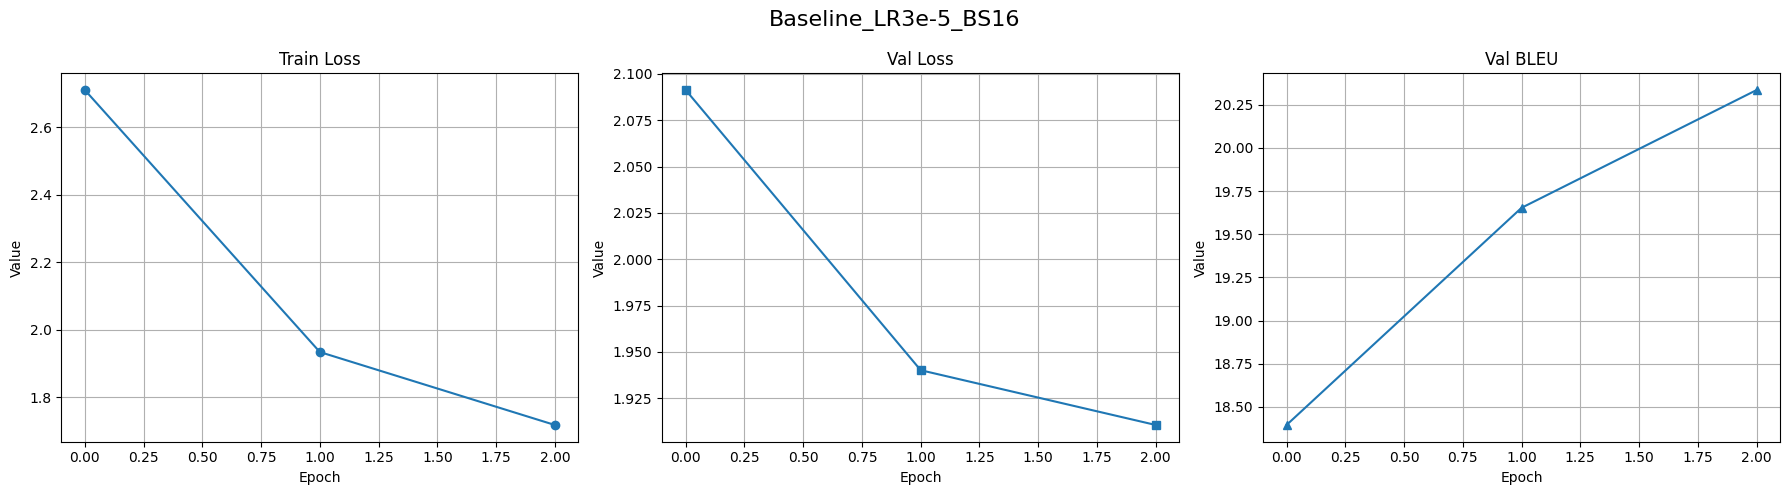

Evaluating: 100%|██████████| 188/188 [02:44<00:00,  1.14it/s]



Running experiment: HigherLR_LR5e-5_BS16

Epoch 1/3


Evaluating: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


Train Loss: 2.5818, Val Loss: 1.9934, Val BLEU: 19.23

Epoch 2/3


Evaluating: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]


Train Loss: 1.7907, Val Loss: 1.8656, Val BLEU: 20.21

Epoch 3/3


Evaluating: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]


Train Loss: 1.5220, Val Loss: 1.8485, Val BLEU: 20.70


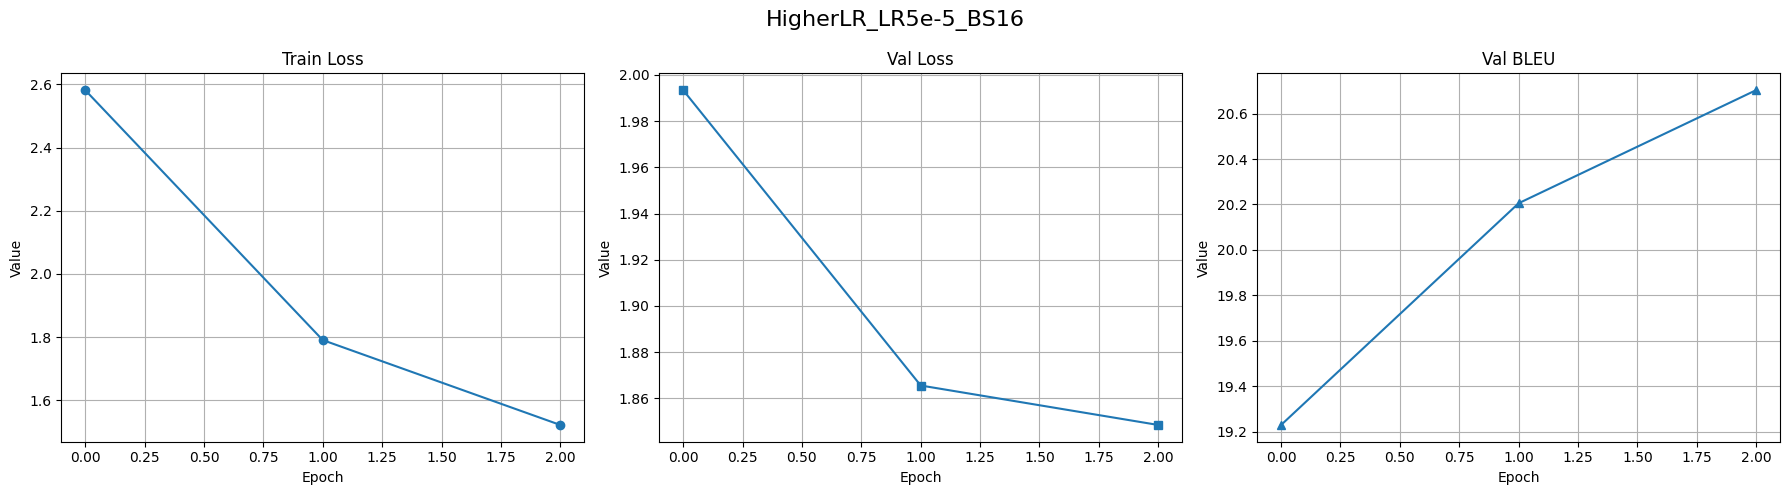

Evaluating: 100%|██████████| 188/188 [02:40<00:00,  1.17it/s]



Running experiment: LargerBatch_LR5e-5_BS32

Epoch 1/3


Evaluating: 100%|██████████| 50/50 [02:38<00:00,  3.18s/it]


Train Loss: 2.6819, Val Loss: 2.0496, Val BLEU: 18.98

Epoch 2/3


Evaluating: 100%|██████████| 50/50 [02:24<00:00,  2.88s/it]


Train Loss: 1.8934, Val Loss: 1.9013, Val BLEU: 20.56

Epoch 3/3


Evaluating: 100%|██████████| 50/50 [02:16<00:00,  2.73s/it]


Train Loss: 1.6583, Val Loss: 1.8779, Val BLEU: 21.10


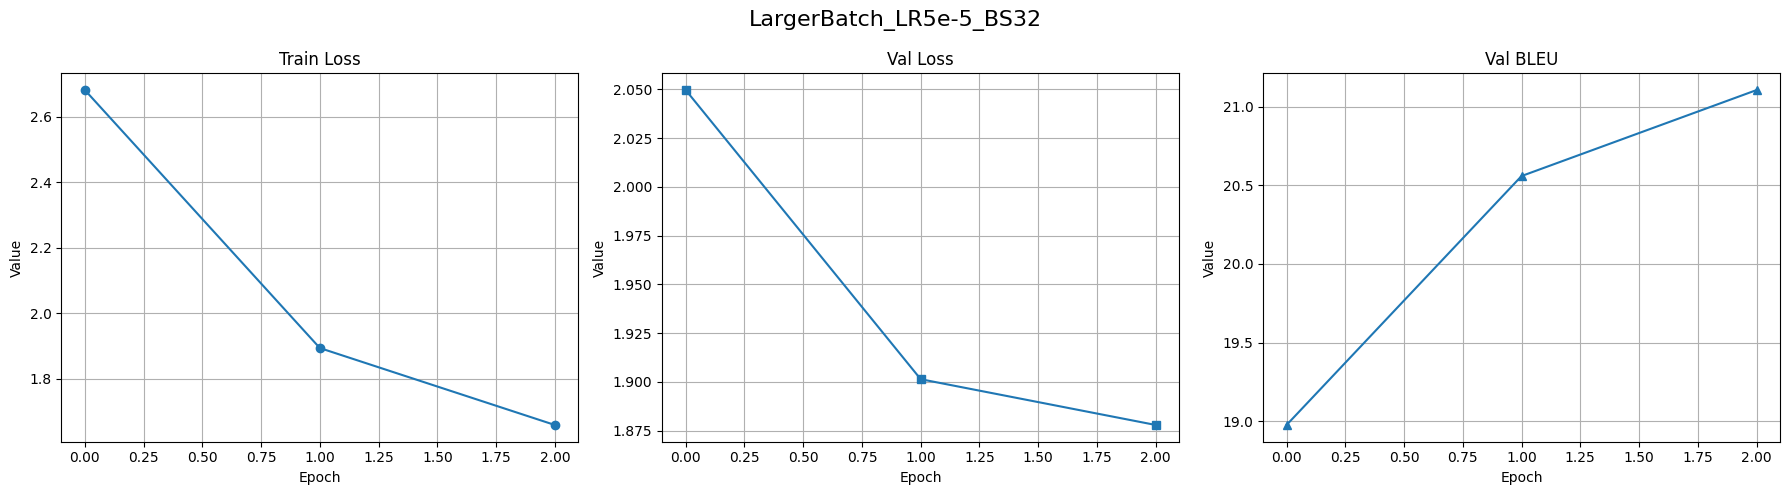

Evaluating: 100%|██████████| 94/94 [04:20<00:00,  2.77s/it]


In [8]:
exp1 = run_single_experiment(
    "Baseline_LR3e-5_BS16",
    train_data, val_data, test_data,
    3e-5, 16, 3,
    model_name="Helsinki-NLP/opus-mt-zh-en",
    custom_zh_sentences=custom_zh_sentences,
    custom_en_sentences=custom_en_sentences
)

exp2 = run_single_experiment(
    "HigherLR_LR5e-5_BS16",
    train_data, val_data, test_data,
    5e-5, 16, 3,
    model_name="Helsinki-NLP/opus-mt-zh-en",
    custom_zh_sentences=custom_zh_sentences,
    custom_en_sentences=custom_en_sentences
)

exp3 = run_single_experiment(
    "LargerBatch_LR5e-5_BS32",
    train_data, val_data, test_data,
    5e-5, 32, 3,
    model_name="Helsinki-NLP/opus-mt-zh-en",
    custom_zh_sentences=custom_zh_sentences,
    custom_en_sentences=custom_en_sentences
)


**Custom Sentence Comparison Output**

- Mandarin to English
- Provides qualitative evidence supporting quantitative BLEU scores.

In [9]:
all_results = [exp1, exp2, exp3]

for r in all_results:
    print(f"\n{'='*80}")
    print(f"Experiment: {r['config_name']}")
    print(f"{'='*80}")
    print(f"Test Loss: {r['test_loss']:.4f}, Test BLEU: {r['test_bleu']:.2f}")

    print("\n--- Custom Sentences ---")
    for i, (src, pred, ref) in enumerate(r['custom_results'], 1):
        print(f"{i}. ZH: {src}")
        print(f"   Predicted EN: {pred}")
        print(f"   Reference EN: {ref}\n")



Experiment: Baseline_LR3e-5_BS16
Test Loss: 1.8589, Test BLEU: 21.44

--- Custom Sentences ---
1. ZH: 警报声响彻整栋大楼，红色的警示灯闪个不停。她跑得气喘吁吁，但仍不敢回头。身后的脚步声越来越近，她知道她已经没有多少时间了。“别再追了！”她喊道，但回应她的，只有更急促的脚步声。
   Predicted EN: The warning speaked over the built, and the red shit started. She run around, but she wondered not to look back. Her foot was nice, and she knew she hadn't got a lot of time. She said, "Get stop following!" but keep back to her, there were more hurried foot.
   Reference EN: Alarms echoed through the entire building, and the red warning lights flashed nonstop. She ran, breathless, but didn’t dare look back. The footsteps behind her were getting closer, and she knew she was running out of time. ‘Stop chasing me!’ she shouted, but the only response was even faster footsteps.


Experiment: HigherLR_LR5e-5_BS16
Test Loss: 1.7983, Test BLEU: 21.72

--- Custom Sentences ---
1. ZH: 警报声响彻整栋大楼，红色的警示灯闪个不停。她跑得气喘吁吁，但仍不敢回头。身后的脚步声越来越近，她知道她已经没有多少时间了。“别再追了！”她喊道，但回应她的，只有更急促的脚步声。
   Predicted EN: T

**Compare Experiments**

- Plots loss and BLEU curves for comparison

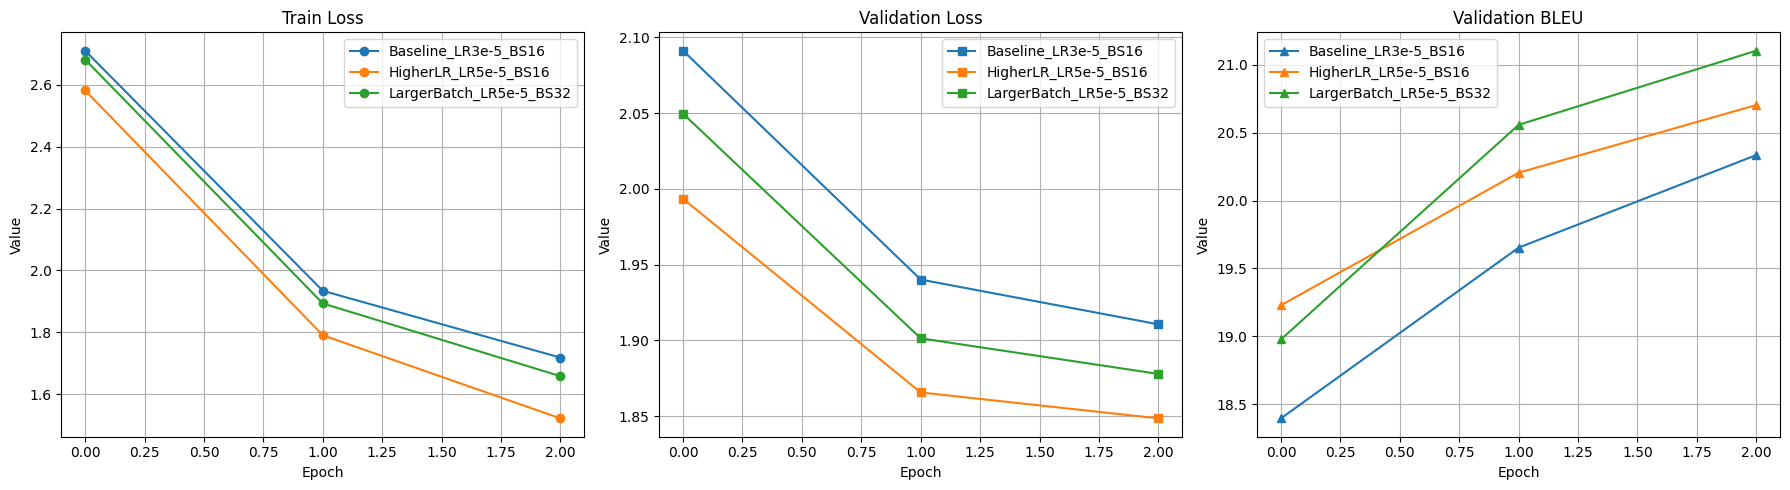

                Experiment  Final Train Loss  Final Val Loss  Final Val BLEU  \
0     Baseline_LR3e-5_BS16          1.718328        1.910591       20.335184   
1     HigherLR_LR5e-5_BS16          1.522005        1.848507       20.703766   
2  LargerBatch_LR5e-5_BS32          1.658340        1.877856       21.104363   

   Test Loss  Test BLEU  
0   1.858872  21.440248  
1   1.798252  21.717740  
2   1.846745  21.542412  


In [12]:
def plot_training_results(histories, labels):
    """
    Plot train loss, validation loss, and validation BLEU
    for multiple experiments on the same figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for history, label in zip(histories, labels):
        axes[0].plot(history['train_loss'], marker='o', label=label)
        axes[1].plot(history['val_loss'], marker='s', label=label)
        axes[2].plot(history['val_bleu'], marker='^', label=label)

    axes[0].set_title("Train Loss")
    axes[1].set_title("Validation Loss")
    axes[2].set_title("Validation BLEU")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

all_results = [exp1, exp2, exp3]
histories = [r['history'] for r in all_results]
labels = [r['config_name'] for r in all_results]

plot_training_results(histories, labels)

# Create comparison table
comparison_data = {
    'Experiment': [r['config_name'] for r in all_results],
    'Final Train Loss': [r['history']['train_loss'][-1] for r in all_results],
    'Final Val Loss': [r['history']['val_loss'][-1] for r in all_results],
    'Final Val BLEU': [r['history']['val_bleu'][-1] for r in all_results],
    'Test Loss': [r['test_loss'] for r in all_results],
    'Test BLEU': [r['test_bleu'] for r in all_results]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison)

